In [20]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.preprocessing import scale

#data from here: https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering
#original data source here: https://archive.ics.uci.edu/ml/datasets/wine

#import data
wine = pd.read_csv("/home/sam/notes/compSci/2611/wk8/wine_clustering.csv")#again, you should put the path on your machine here
wine.head()



,Label,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [21]:
#grab "ground truth" labels
labels = wine["Label"]

#remove labels from data set to use for clustering
dataForClustering = pd.DataFrame(scale(wine.loc[:, wine.columns != "Label"]))
dataForClustering.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [22]:
km_clust = KMeans(3) #declare model
km_clust.fit(dataForClustering) #fit model to data

#look at labels
km_clust.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [23]:
#if you have known labels, the "rand score" is similar to the accuracy score
# we calculated when doing supervised learning (its in fact the same if there
#are only two classes). If labels are not known, rand score can tell you the
#similarity between two different clustering methods
metrics.rand_score(labels, km_clust.labels_)

0.9620389767028502

In [24]:
# if you do not have ground truth labels, you can evaluate clusters by 
# looking at how separated they are in n-dimensional space
#lower values are better - only useful if you want to compare to other clustering metrics
metrics.davies_bouldin_score(dataForClustering, km_clust.labels_)

1.391793832317738

# How to visualize clusters?
N-dimensional data exists n-dimensional space (for example, the iris data has 4 columns and would then be plotted in 4-dimensional space). To visualize these clusters, we would like to compress the data into 2 dimensions. This process is called **dimensionality reduction**. Principal components analysis is the most common way to do this (but there are many others as well). 

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) #determine how many dimensions you want output
components = pca.fit_transform(dataForClustering)
# for a data set with n rows, will return an nx2 numpy array
print(type(components))
print(components)

<class 'numpy.ndarray'>
[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]
 [ 3.05025392  2.12240111]
 [ 2.44908967  1.17485013]
 [ 2.05943687  1.60896307]
 [ 2.5108743   0.91807096]
 [ 2.75362819  0.78943767]
 [ 3.47973668  1.30233324]
 [ 1.7547529   0.61197723]
 [ 2.11346234  0.67570634]
 [ 3.45815682  1.13062988]
 [ 4.31278391  2.09597558]
 [ 2.3051882   1.66255173]
 [ 2.17195527  2.32730534]
 [ 1.89897118  1.63136888]
 [ 3.54198508  2.51834367]
 [ 2.0845222   1.06113799]
 [ 3.12440254  0.78689711]
 [ 1.08657007  0.24174355]
 [ 2.53522408 -0.09184062]
 [ 1.64498834 -0.51627893]
 [ 1.76157587 -0.31714893]
 [ 0.9900791   0.94066734]
 [ 1.77527763  0.68617513]
 [ 1.23542396 -0.08980704]
 [ 2.18840633  0.68956962]
 [ 2.25610898  0.19146194]
 [ 2.50022003  1.24083383]
 [ 2.67741105  1.47187365]
 [ 1.62857912  0.05270445]
 [ 1.90269086  1.63306043]
 [ 1.41038853  0.69793432]
 [ 1.90382623  0.17671095]
 [ 1

Text(0, 0.5, 'PC 2')

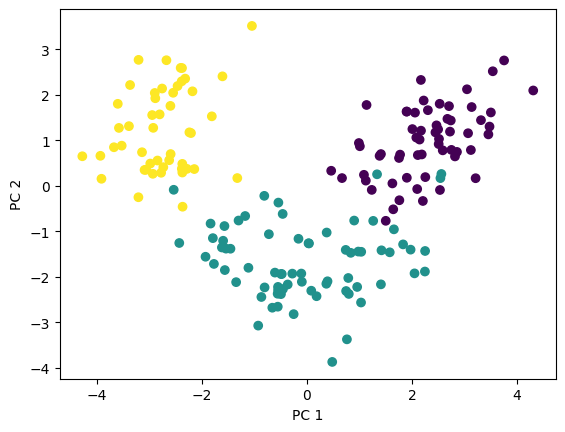

In [26]:
import matplotlib.pyplot as plt

# we can plot these colored by the labels we calculated to see if 
# the clusters seem to fit based on the data
plt.scatter(components[:,0], components[:,1], c = labels)
plt.xlabel("PC 1")
plt.ylabel("PC 2")


In [27]:
# a common way to evaluate pca is "% varience explained"
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

# Hierarchical clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering

#We'll start by letting the clustering algorithm try to deterine
# wine clusters
hier_clust = AgglomerativeClustering()
hier_clust.fit(dataForClustering)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [29]:
# How many clusters did the algorithm find?
hier_clust.n_clusters

2

Text(0, 0.5, 'PC 2')

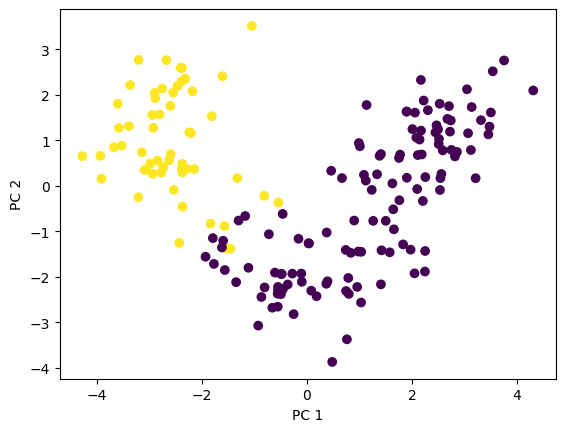

In [30]:
# lets see how it did the clustering
plt.scatter(components[:,0], components[:,1], c = hier_clust.labels_)
plt.xlabel("PC 1")
plt.ylabel("PC 2")



In [31]:
# obviously, because the algorithm made two clusters when we know that there 
# are three different vinyards, this algorithm is not going to have
# a very good Rand index (accuracy)

metrics.rand_score(labels, hier_clust.labels_)

0.7076747286231194

In [32]:
# does the algorithm do better if we force 3 clusters?
hier_clust2 = AgglomerativeClustering(n_clusters = 3)
hier_clust2.fit(dataForClustering)
metrics.rand_score(labels, hier_clust2.labels_)

0.9064940011426394

Text(0, 0.5, 'PC 2')

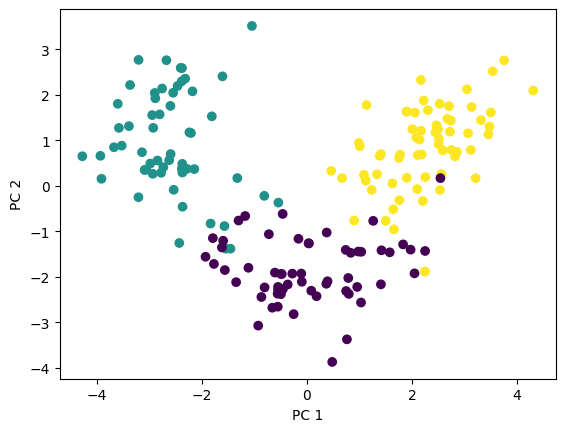

In [33]:
# we got a worse rand score as using k-means clustering
# How similar are the two clustering algorithms?
# lets see how it did the clustering
plt.scatter(components[:,0], components[:,1], c = hier_clust2.labels_)
plt.xlabel("PC 1")
plt.ylabel("PC 2")



In [34]:
# We can verify this using rand index
# to compare the two clustering algorithm's outputs
metrics.rand_score(km_clust.labels_, hier_clust2.labels_)

0.9273154319812099

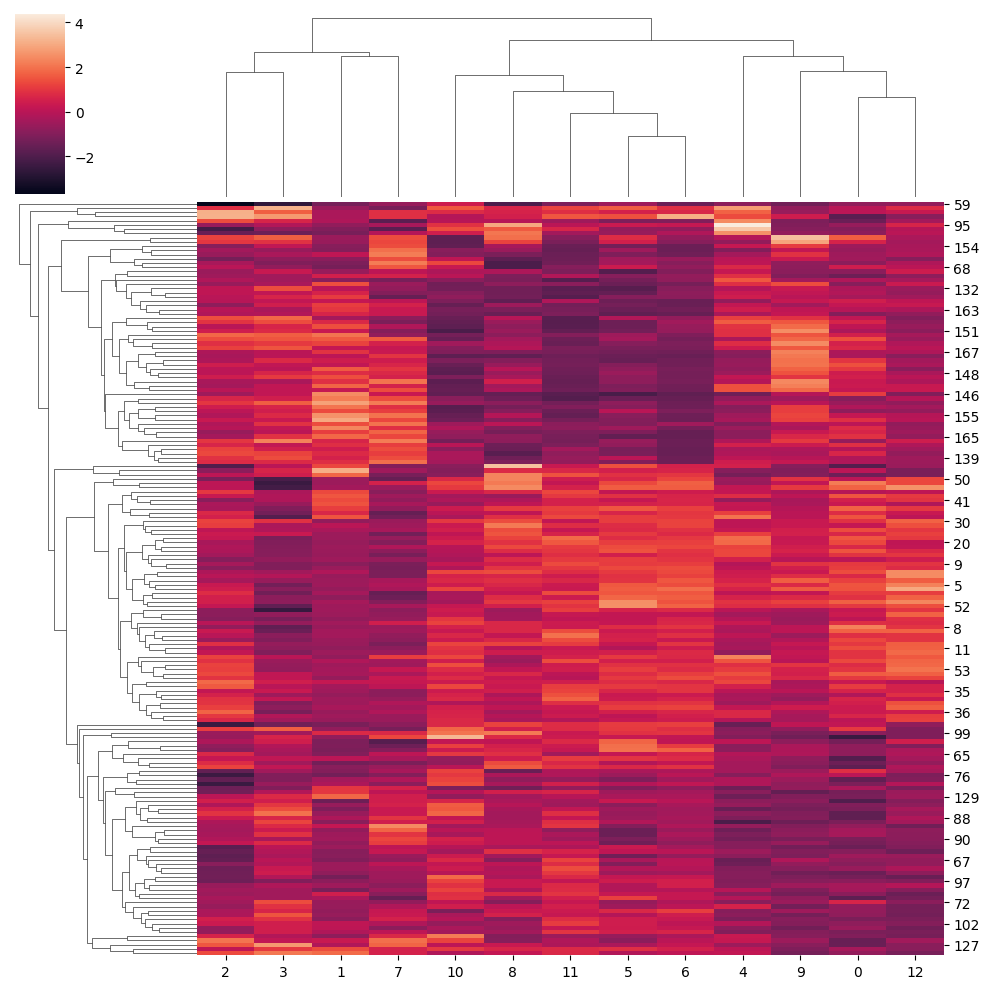

In [35]:
# so what is actually going on with hierarchical clustering? 
# one of the outputs of a hierarchical clustering algorithm is 
# a tree called a dendrogram. Lets look at one:
import seaborn as sns
sns.clustermap(dataForClustering)

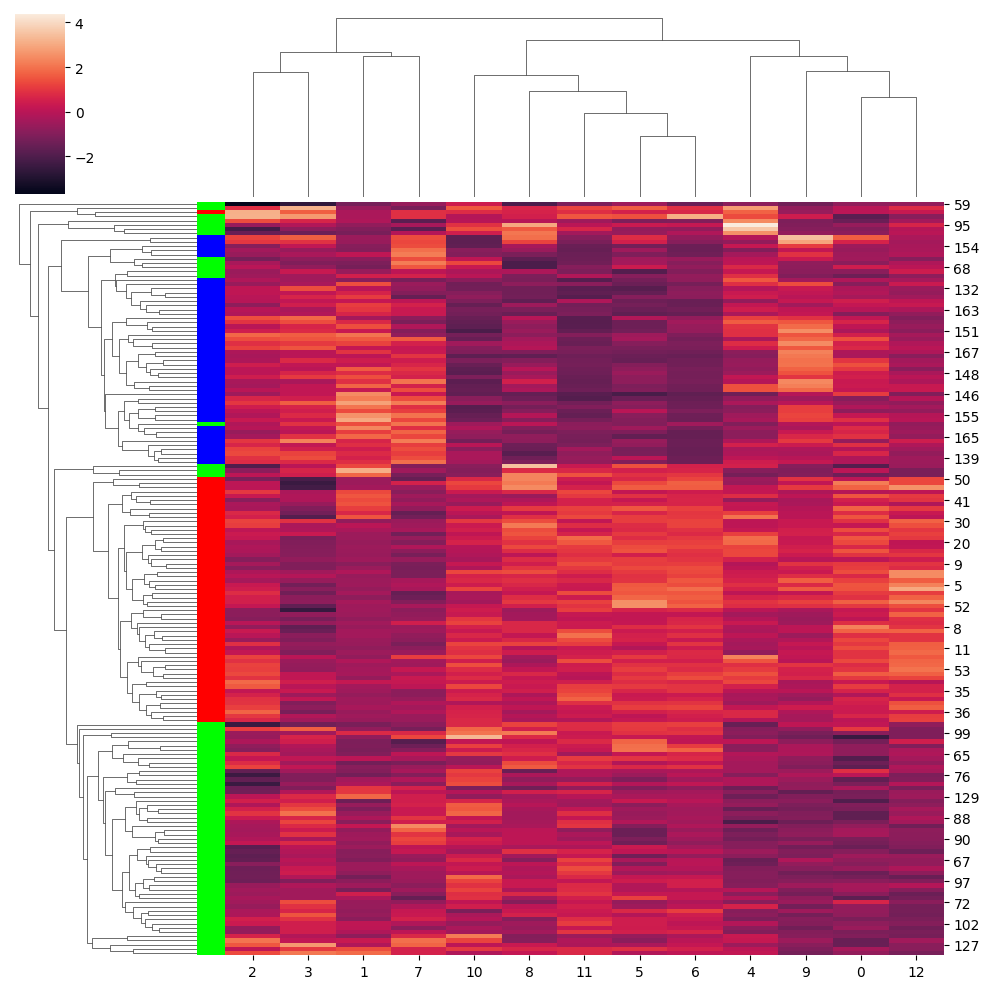

In [36]:
# we can add colors for the labels on the observations to see more clearly 
# what is going on in the data
rgb = []
for i in labels:
    if i == 1:
        rgb.append((1,0,0)) #rgb code for red
    elif i == 2:
        rgb.append((0,1,0)) #rgb code for green
    elif i == 3:
        rgb.append((0,0,1)) #rgb code for blue
        
sns.clustermap(dataForClustering, row_colors = rgb)

# Your turn - determine how many different types of customers you thing a mall should try to target with targeted advertising

Download Mall_Customers.csv from canvas and see what you can find

I would recommend doing the following steps:

1) do pca on the data set and plot it to get a visual of how the data looks (already done for you)

2) use one of the clustering methods varying the number of clusters and determine the davies-bouldin score (because we don't know the labels)

3) judge which number of clusters you think is best

4) Display the graph illustrating how many clusters you think is best (you should have each cluster have a distinct color)

Text(0, 0.5, 'PC 2')

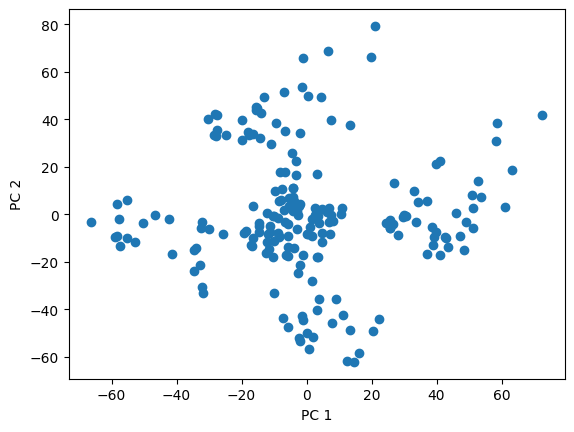

In [37]:
mall = pd.read_csv("/home/sam/notes/compSci/2611/wk8/Mall_Customers.csv")

# do PCA first
pca = PCA(n_components=2) # say how many dimensions you want
components = pca.fit_transform(mall)

plt.scatter(components[:,0], components[:,1])
plt.xlabel("PC 1")
plt.ylabel("PC 2")

Best k by Davies-Bouldin: 6 (DB=0.8350)


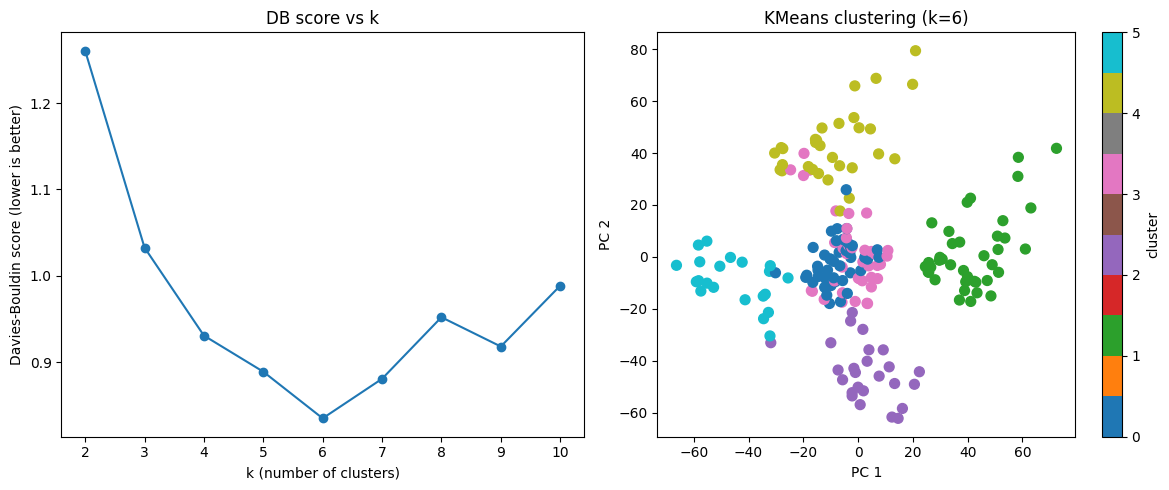

In [38]:
# vary number of clusters, compute Davies-Bouldin, pick best, and plot
mall_scaled = scale(mall)  # scale features before clustering

ks = range(2, 11)
db_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    labs = km.fit_predict(mall_scaled)
    db_scores.append(metrics.davies_bouldin_score(mall_scaled, labs))

# pick best k (lowest Davies-Bouldin)
best_score = min(db_scores)
best_k = list(ks)[db_scores.index(best_score)]
print(f"Best k by Davies-Bouldin: {best_k} (DB={best_score:.4f})")

# fit final model with best_k
final_km = KMeans(n_clusters=best_k, random_state=42)
final_labels = final_km.fit_predict(mall_scaled)

# plot DB vs k and PCA scatter colored by chosen clusters
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(list(ks), db_scores, marker='o')
plt.xticks(list(ks))
plt.xlabel("k (number of clusters)")
plt.ylabel("Davies-Bouldin score (lower is better)")
plt.title("DB score vs k")

plt.subplot(1,2,2)
sc = plt.scatter(components[:,0], components[:,1], c=final_labels, cmap='tab10', s=50)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title(f"KMeans clustering (k={best_k})")
plt.colorbar(sc, ticks=range(best_k), label="cluster")

plt.tight_layout()